<a href="https://colab.research.google.com/github/CarlosPossi/Engenharia_De_Software/blob/main/Exercicios_da_Aula_7_%7C_Eng_Software.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🏋️ Exercício Prático — Miro + Draw.io + Google Colab**

**Contexto:**
<br>
Você vai modelar o fluxo de sacar dinheiro no app do Nubank.

### **Parte 1 — Diagrama no Miro 🗺️**
**Participantes:**
* Usuário
* App Nubank
* Servidor Nubank
* Banco de Dados
<br>

**Fluxo a modelar (cenário feliz):**
* Usuário toca em "Transferir"
* App solicita valor e destinatário
* Usuário confirma
* App envia solicitação ao servidor
* Servidor verifica saldo no banco de dados
* Servidor autoriza e debita o saldo
* App exibe confirmação ao usuário
<br>

**Instruções:**
* Acesse o template de Diagrama de Sequência no Miro
* Crie os participantes (caixas no topo)
* Trace as lifelines (linhas verticais)
* Adicione as mensagens com setas e nomes
<br>

**🗺️ Diagrama de Sequência:**

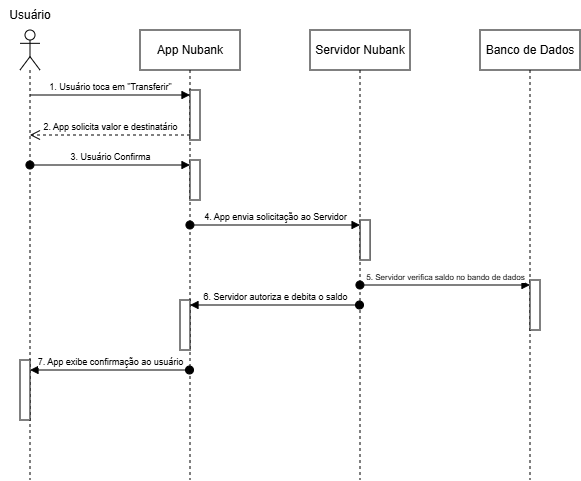

**Comentário sobre o que o diagrama representa e as decisões de modelagem:**
<br>
O diagrama representa um fluxo de transferência no app Nubank, mostrando a interação sequencial entre Usuário, App, Servidor e Banco de Dados até a confirmação da operação.
A modelagem utiliza um diagrama de sequência para evidenciar a ordem temporal das mensagens e responsabilidades de cada componente no processo.
As decisões de modelagem destacam a separação de camadas (interface, lógica de negócio e persistência), garantindo clareza no fluxo e na comunicação entre sistemas.

### Parte 2 — Código no Google Colab 🐍
O esqueleto do código abaixo representa o diagrama que você acabou de modelar no Miro.

**Célula 1 — BancoDeDados (Participante 4)**

In [ ]:
class BancoDeDados:
    def __init__(self):
      self.saldos = {
          "user_123": 500.0
      }

    def verificar_saldo(self, user_id: str) -> float:
      return self.saldos.get(user_id, 0.0)

    def debitar(self, user_id: str, valor: float) -> bool:
      saldo_atual = self.saldos.get(user_id, 0.0)

      if self.saldos.get(user_id, 0.0) >= valor:
        self.saldos[user_id] = saldo_atual - valor
        return True
      else:
        return False

**Célula 2 — ServidorNubank (Participante 3)**

In [ ]:
class ServidorNubank:
    def __init__(self):
        self.banco = BancoDeDados()

    def processar_transferencia(self, user_id: str, valor: float) -> dict:
      saldo_atual = self.banco.verificar_saldo(user_id)

      if saldo_atual >= valor:
        self.banco.debitar(user_id, valor)
        return {
            "status": "aprovado",
            "saldo_restante": saldo_atual - valor
        }
      else:
        return {
            "status": "recusado",
            "motivo": "saldo insuficiente"
        }

**Célula 3 — AppNubank (Participante 2)**

In [ ]:
class AppNubank:
    def __init__(self):
        self.servidor = ServidorNubank()

    def transferir(self, user_id: str, valor: float):
        print(f"[APP] Iniciando transferência de R$ {valor:.2f}...")

        resultado = self.servidor.processar_transferencia(user_id, valor)

        if resultado["status"] == "aprovado":
          print(f"✅ Transferência aprovada! Saldo restante: {resultado['saldo_restante']}")

        else:
          print(f"❌ Transferência recusada. Motivo: {resultado['motivo']}")

**Célula 4 — Testes (não altere, apenas execute)**

In [ ]:
# Rode esta célula só depois de completar as anteriores!
app = AppNubank()
print("=== Teste 1: Transferência dentro do saldo ===")

app.transferir("user_123", 200.0)   # Esperado: ✅ aprovado
print("\n=== Teste 2: Transferência acima do saldo ===")

app.transferir("user_123", 500.0)   # Esperado: ❌ recusado
print("\n=== Teste 3: Múltiplas transferências ===")

app.transferir("user_123", 100.0)   # Esperado: ✅ aprovado (saldo agora 200)
app.transferir("user_123", 250.0)   # Esperado: ❌ recusado (saldo insuficiente)

=== Teste 1: Transferência dentro do saldo ===
[APP] Iniciando transferência de R$ 200.00...
✅ Transferência aprovada! Saldo restante: 300.0

=== Teste 2: Transferência acima do saldo ===
[APP] Iniciando transferência de R$ 500.00...
❌ Transferência recusada. Motivo: saldo insuficiente

=== Teste 3: Múltiplas transferências ===
[APP] Iniciando transferência de R$ 100.00...
✅ Transferência aprovada! Saldo restante: 200.0
[APP] Iniciando transferência de R$ 250.00...
❌ Transferência recusada. Motivo: saldo insuficiente


**Comentário sobre o que o código implementa e o que foi aprendido:**
<br>
O código implementa uma simulação de sistema de transferência inspirado no fluxo do Nubank, separando responsabilidades entre App, Servidor e Banco de Dados.
Ele modela a verificação de saldo, validação de transação e atualização de estado, seguindo a arquitetura em camadas do diagrama de sequência.
O principal aprendizado é como a divisão de responsabilidades entre classes melhora a organização do sistema e reflete diretamente a comunicação entre componentes reais de um sistema financeiro.

**Comentário sobre o output exibido**
<br>
O output mostra a execução do fluxo de transferências no sistema, validando corretamente cenários de aprovação e recusa com base no saldo disponível do usuário.
As mensagens indicam que o sistema atualiza o saldo após cada operação, mantendo consistência no estado da conta entre as transações.
Isso demonstra que a comunicação entre App, Servidor e Banco de Dados está funcionando conforme o fluxo modelado no diagrama de sequência.
